# Data Cleaning

---

## 1. Introduction to Data Cleaning
Data cleaning is a crucial step in data processing. This section covers techniques for handling issues like inconsistent time formats, missing values, and outliers.

---

## 2. Time and Date Alignment

Aligning temporal data from different sources can be challenging. Common formats include UTC, GMT, and Unix time.



In [1]:
from datetime import datetime

# Sample conversion to UTC
date_str = "2023-11-05 15:45:32"
date_obj = datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")

print("Original:", date_obj)
print("Converted to Unix timestamp:", date_obj.timestamp())

Original: 2023-11-05 15:45:32
Converted to Unix timestamp: 1699224332.0



---


## 3. Handling Missing Values

Missing data is a common issue in datasets. Here, we explore techniques for imputation.

### Types of Imputation:
- **Mean Imputation**: Replace missing values with the mean of the column.
- **Nearest Neighbor Imputation**: Use the closest data points to estimate missing values.
- **Heuristic Imputation**: Estimate based on known rules (e.g., death year = birth year + 80).



In [4]:
import pandas as pd
import numpy as np

data = pd.DataFrame({"age": [25, np.nan, 30, 45, np.nan]})
print("Data with missing values:")
print(data)

data["age_filled"] = data["age"].fillna(data["age"].mean())
print("Data with missing values filled with the mean:")
print(data)

Data with missing values:
    age
0  25.0
1   NaN
2  30.0
3  45.0
4   NaN
Data with missing values filled with the mean:
    age  age_filled
0  25.0   25.000000
1   NaN   33.333333
2  30.0   30.000000
3  45.0   45.000000
4   NaN   33.333333



---

## 4. Outlier Detection

Outliers can distort analysis. Identifying them is essential for high-quality data.

### Methods:
- **Clustering**: Identify points far from cluster centers.
- **Distribution Analysis**: Check for anomalies in normally distributed data.



In [12]:
from scipy.stats import zscore

data = pd.DataFrame({"value": [10, 12, 12, 13, 900]})
data["z_score"] = zscore(data["value"])
data["is_outlier"] = data["z_score"].abs() > 1.99  # Threshold for outlier detection (use 1.99 for rounding precision)

print("Sample data with potential outlier:")
print(data)

Sample data with potential outlier:
   value   z_score  is_outlier
0     10 -0.504924       False
1     12 -0.499294       False
2     12 -0.499294       False
3     13 -0.496480       False
4    900  1.999992        True


---

# Data Visualization

Data visualization is essential for exploring data patterns and spotting issues.



### Importance of Visualization
- Identifying data issues
- Observing patterns
- Hypothesis generation


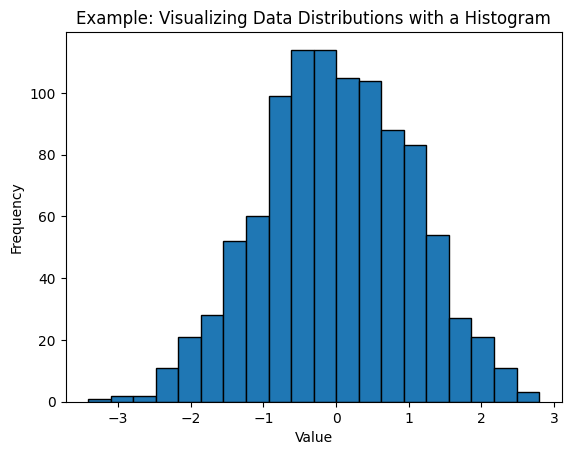

In [13]:
import matplotlib.pyplot as plt

data = np.random.normal(size=1000)
plt.hist(data, bins=20, edgecolor="black")
plt.title("Example: Visualizing Data Distributions with a Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


---

## 6. Scatter Plots for Relationships Between Variables

Scatter plots are useful for examining relationships between two variables.

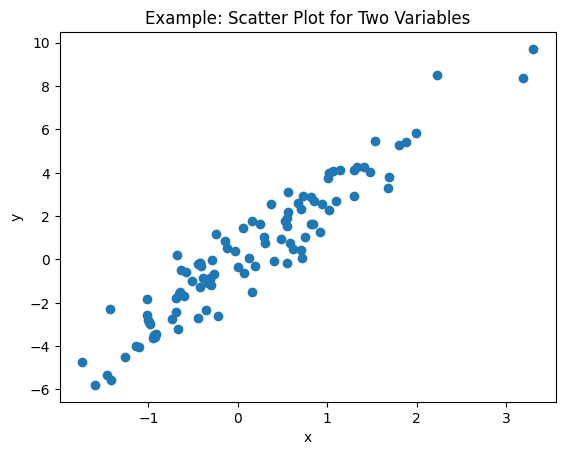

In [14]:
x = np.random.normal(size=100)
y = x * 3 + np.random.normal(size=100)
plt.scatter(x, y)
plt.title("Example: Scatter Plot for Two Variables")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



---

# Graphical Integrity




## 1. Lie Factor

$$
\text{Lie Factor} = \frac{\text{size of effect shown in graphic}}{\text{size of effect in data}}
$$

> most important factor in determining graphical integrity


The Lie Factor is a numeric value that can actually be calculated (it's not just a concept), and it helps to quantify how much a graphic exaggerates (or downplays) the effect shown in the actual dat

A Lie Factor close to 1 indicates an accurate representation, while values far from 1 (e.g., much greater than 1) suggest distortion.



#### Visualizing the Lie Factor

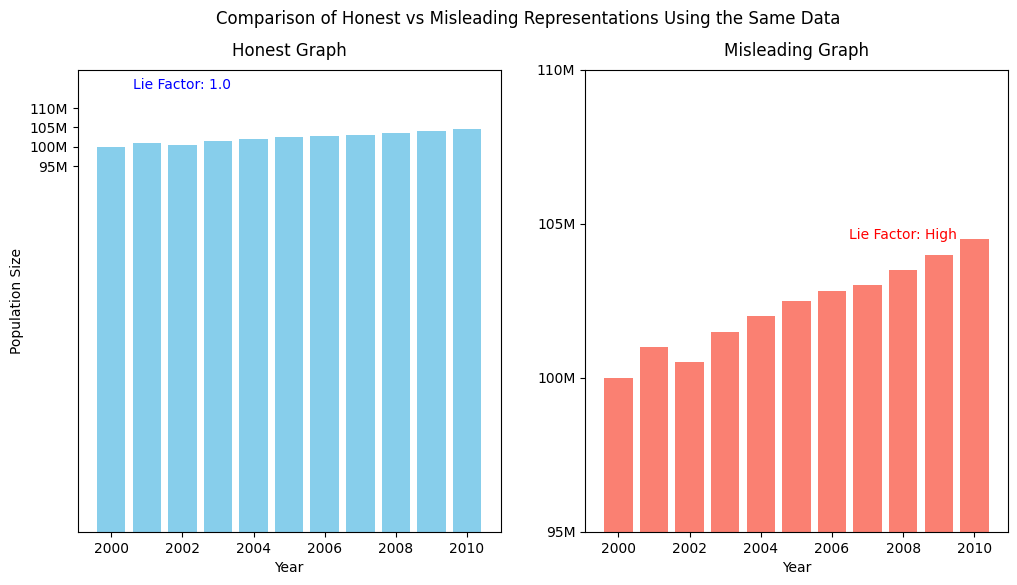

In [8]:
# Example data: Population over years with slight variations (hypothetical values for demonstration)
years = np.arange(2000, 2011, 1)
actual_population = [100_000_000, 101_000_000, 100_500_000, 101_500_000, 102_000_000,
                     102_500_000, 102_800_000, 103_000_000, 103_500_000, 104_000_000, 104_500_000]

# Misleading representation (artificial increase for visual impact)
misleading_population = [40_000_000, 55_000_000, 60_000_000, 70_000_000, 80_000_000,
                         90_000_000, 95_000_000, 100_000_000, 105_000_000, 110_000_000, 115_000_000]

# Calculate Lie Factor
actual_change = (actual_population[-1] - actual_population[0]) / actual_population[0] * 100
visual_change = (misleading_population[-1] - misleading_population[0]) / misleading_population[0] * 100
lie_factor = visual_change / actual_change

# Plotting both the honest and misleading representations side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Honest representation
ax[0].bar(years, actual_population, color='skyblue')
ax[0].set_ylim(0, 120_000_000)  # Honest y-axis scale that starts at 0
ax[0].set_title("Honest Graph", pad=10)
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Population Size")

# Misleading representation with adjusted y-axis scale to create distortion
ax[1].bar(years, actual_population, color='salmon')
ax[1].set_ylim(95_000_000, 105_000_000)  # Narrow y-axis range to exaggerate differences
ax[1].set_title("Misleading Graph", pad=10)
ax[1].set_xlabel("Year")

# Set y-axis labels as realistic population numbers for both graphs
for axis in ax:
    axis.set_yticks([95_000_000, 100_000_000, 105_000_000, 110_000_000])
    axis.set_yticklabels(['95M', '100M', '105M', '110M'])

plt.suptitle("Comparison of Honest vs Misleading Representations Using the Same Data")
plt.show()

> The lie factor is 1 (no distortion) for the graphic on the left because the actual effect size/range corresponds with the effect size shown visually (~4.5%) 

In [16]:
# Calculate the average population value
average_population = np.mean(actual_population)

# Calculate the variance and standard deviation of the population values
std_dev_population = np.std(actual_population)
variance_population = np.var(actual_population)

# Calculate the absolute change from start to end as a percentage of the average
percentage_deviation = (abs(actual_population[-1] - actual_population[0]) / average_population) * 100

# Calculate the variance range
variance_range = max(actual_population) - min(actual_population)

honest_y_range = max(actual_population)
misleading_y_range = 105_000_000 - 95_000_000  # The misleading graph's y-axis range

honest_deviation = (variance_range / honest_y_range) * 100
misleading_deviation = (variance_range / misleading_y_range) * 100

# Print the calculated deviation
print(f"Deviation as a Percentage of Average Value: {percentage_deviation:.1f}%")
print(f"⇒ the bars should vary ~{percentage_deviation:.1f}% of graph height")
print(f"\nThe honest graph's bars vary by ~{honest_deviation:.1f}% of the y-axis.")
print(f"The misleading graph's bars vary by ~{misleading_deviation:.1f}% of the y-axis.")

Deviation as a Percentage of Average Value: 4.4%
⇒ the bars should vary ~4.4% of graph height

The honest graph's bars vary by ~4.3% of the y-axis.
The misleading graph's bars vary by ~45.0% of the y-axis.


---

## 2. Graphical Integrity: Visual Area and Numerical Measure

Another important factor in determining the graphical integrity of a graphic is the visual area of the effect shown in the graphic. 

The visual area is the area of the effect shown in the graphic - calculated as area of the effect shown in the graphic divided by the area of the effect in the data.

> Using area or volume to represent one-dimensional data often leads to misinterpretation. The size of a visual representation should match the magnitude of the data it represents.



### Offset Distortion

Offset distortion is the distortion of the data due to the offset of the scale.

> Start bar graphs at 0

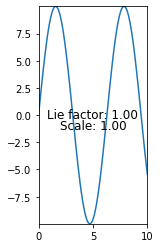

In [8]:
# Create example figure with offset distortion issue
fig, ax = plt.subplots()
x = np.linspace(0, 10, 100)
y = np.sin(x)
y = y * 10
ax.plot(x, y)

# Visualize the lie factor
data = {'x': x, 'y': y}
lie_factor = visualize_lie_factor(ax, data, scale=1)


### Scale Distortion

Scale distortion is the distortion of the data due to the scale of the graph.

> Use a consistent scale

Text(0.5, 1.0, 'Life Expectancy Over Time')

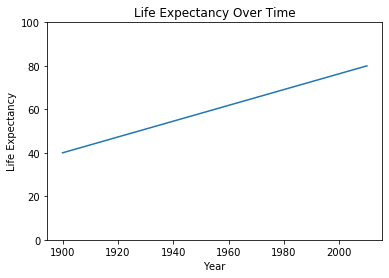

In [11]:
# Create example figure with scale distortion issue (life expecteancy over time)

fig, ax = plt.subplots()
years = np.arange(1900, 2020, 10)
life_expectancy = np.linspace(40, 80, len(years))

# Force y-axis to start at 0
ax.set_ylim(0, 100)

ax.plot(years, life_expectancy)
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy')
ax.set_title('Life Expectancy Over Time')


### Omitting Context

Omitting context is the distortion of the data due to the omission of context.

> Graphics must not quote data out of context: there should always be a frame of reference


---


## 3. Data-Ink Ratio

> If visualization with less ink possible, do so

$$
\text{Data-Ink Ratio} = \frac{\text{Data-Ink}}{\text{Total-Ink}}
$$

**Goal**: Maximize the data-ink ratio (i.e., minimize the non-data ink)

### Elements of Plots that can be Removed to Increase Data-Ink Ratio

- Gridlines
- Borders
- Background colors
- Axis lines

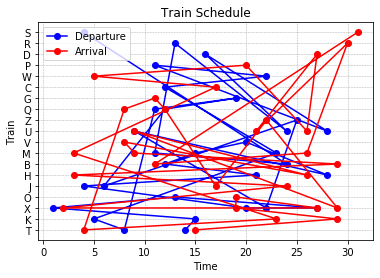

In [16]:
import random
def visualize_marey_train_schedule(n: int = 7):
    fig, ax = plt.subplots()

    # Train schedule
    alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    trains = random.choices(alphabet, k=n)
    departure = np.random.randint(1, n, len(trains))
    arrival = np.random.randint(1, n, len(trains))

    # Add gridlines
    ax.grid(True, which='both', linestyle='--', lw=0.5)

    # Plot the train schedule
    ax.plot(departure, trains, 'bo-', label='Departure')
    ax.plot(arrival, trains, 'ro-', label='Arrival')

    # Add labels
    ax.set_xlabel('Time')
    ax.set_ylabel('Train')
    ax.set_title('Train Schedule')
    ax.legend()

    return fig, ax

fig, ax = visualize_marey_train_schedule(32)

## Tabular Data

### Improvements

-  

In [24]:
def create_example_table(n: int = 12):
    """Country | Area | Density | Population | Mortality | GDP"""
    countries = [
        'USA',
        'China',
        'India',
        'Brazil',
        'Russia',
        'Japan',
        'Germany',
        'UK',
        'France',
        'Italy',
        'Canada',
        'South Korea',
    ]
    columns = ['Country', 'Area', 'Density', 'Population', 'Mortality', 'GDP']
    fig, ax = plt.subplots()
    ax.axis('off')
    ax.table(cellText=data, colLabels=columns, loc='center')
    return fig, ax

## Line Charts

**Line Chart**: Series of data points connected with lines

May make sense with time series data

> If no meaningful adjacency between data points, don't use line chart -- instead overlay fitted curve



In [ ]:
def line_chart():
    fig, ax = plt.subplots()
    x = np.linspace(0, 10, 100)
    y = np.sin(x)
    ax.set_title('Line Chart without Fitted Curve')
    ax.plot(x, y)

    return fig, ax

def line_chart_with_fitted_curve_overlay():
    fig, ax = plt.subplots()
    x = np.linspace(0, 10, 100)
    y = np.sin(x)
    ax.plot(x, y)
    z = np.polyfit(x, y, 3)
    p = np.poly1d(z)
    ax.plot(x, p(x), 'r--')
    return fig, ax



## Scatter Plots

Heat map for better frequency visualization

### Color

> Colored heat map reveals the distribution (density) better

### Dot Size

> Large dot size $\rightarrow$

### Jittering

Add random noise $\epsilon$ to $x$ and/or $y$ coordinates to avoid overplotting

### Visualizing more than 2 Variables

> Use size, color, shape, etc. to visualize relations across the extra dimensions

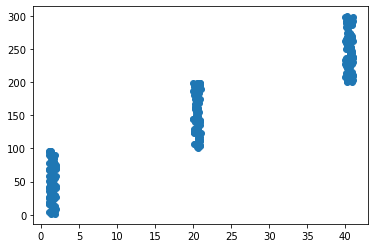

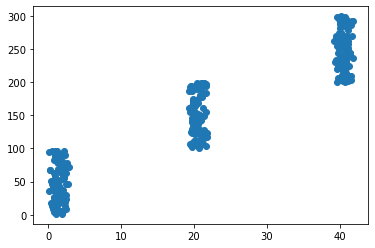

In [ ]:
n = 100

# Generate data with strong correlation
np.random.seed(0)
# x in [1, 2] or [20, 21] or [40, 41]
# y in [0, 200]
x = np.concatenate([np.random.uniform(1, 2, n), np.random.uniform(20, 21, n), np.random.uniform(40, 41, n)])
y = np.concatenate([np.random.uniform(0, 100, n), np.random.uniform(100, 200, n), np.random.uniform(200, 300, n)])

plt.scatter(x, y)
plt.title('Scatter Plot with Strong Correlation')
plt.show()

# Create second plot with jittering
jitter = 1
x_jitter = x + np.random.uniform(-jitter, jitter, len(x))

plt.scatter(x_jitter, y)
plt.title('Scatter Plot with Jittering')
plt.show()

## Transformations

> Better visualize/understand relationship between variables

- Few outliers at large $x$: log transformation of $x$
- Heavy density at large $y$: power transformation of $y$
- Heavy density at small $y$: inverse transformation of $y$
- Heavy density at both ends: arcsine transformation of $y$
- Heavy density at the center: square root transformation of $y$
- Heavy density at the center and both ends: logit transformation of $y$

### Tukey-Mosteller Bulge Diagram

Guide for finding suitable transformation





# Modeling

> **Modeling** Process of encapsulating info into a tool which can make predictions/forecasts

*Idealized representation* of a system.



---

## 1. First-Principle vs. Data-Driven Models

*Newton's Law of Gravitation* vs. *Predicting Flight Delays*

### First-Principle Models

- May have Bias
- Based on fundamental principles
- Simple to understand
- Require domain knowledge

### Data-Driven Models

- May overfit
- Based on data
- Complex
- Black-box


---

## 2. Principles of Modeling

### Occam's Razor

> The simplest explanation is the best explanation. Minimize the num of model params. Inherent trade-off between accuracy and simplicity

### Bias-Variance Tradeoff

- **Bias**: Error from erroneous assumptions in the learning algorithm (built into the model)
  - $Bias = E[\hat{f}(x)] - f(x) = $ Average deviation of the model from the true function
  - **Underfitting**: interpolation function linear rather than a higher-order polynomial

- **Variance**: Error from sensitivity to 'small' fluctuations in the training set
  - $Variance = E[\hat{f}(x) - E[\hat{f}(x)]] = $ Spread of the model
  - **Overfitting**: model is too complex, fits the noise in the datai


---

## 3. Modeling Pipeline

### Steps

#### Choose a Model

How should we represent the world

If complicated function, may need a complex model

#### Choose a loss function

How do we quantify prediction error?

How do we define the prediction error?

#### Fit the Model

Find a good function that will predict the variable $y$ with the loss function being minimized.

Minmize the errors and fitting the specific parameters that will minimize the loss function.

#### Evaluate the Model Performance

How do we know if the model is good?

In [17]:
# Example Code: Simple Linear Regression Model Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([1, 2.1, 2.9, 4.1, 4.9])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model selection and fitting
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 0.013061224489795928


## Model Types

| Feature 1 | Feature 2 | Feature 3 | $\ldots$ | $\ldots$ | Feature p | Output |
|---|---|---|---|---|---|---|
| $x_11$ | $x_12$ | $x_13$ | $\ldots$ |$\ldots$ | $x_{1p}$ | $y_1$ |
| $x_21$ | $x_22$ | $x_23$ |$\ldots$ |$\ldots$ | $x_{2p}$ | $y_2$ |
| $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$| $\ldots$| $\ldots$ | $\ldots$ |
| $x_{n1}$ | $x_{n2}$ | $x_{n3}$ | $\ldots$|$\ldots$ | $x_{np}$ | $y_n$ |


- Columns correspond to features in the data
- Rows correspond to observations
- Target variable is a categorical variable


### Classification vs. Prediction

#### Classification

- Predicting a categorical variable

#### Prediction

- Predicting a numerical variable

In [18]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Load data and train classifier
iris = load_iris()
clf = DecisionTreeClassifier()
clf.fit(iris.data, iris.target)

# Predicting class (classification)
predicted_class = clf.predict([iris.data[0]])
print("Predicted Class:", predicted_class)

Predicted Class: [0]
